<a href="https://colab.research.google.com/github/adnanaemster/heart-attack-prediction/blob/main/heartattack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os

zip_file_path = '/content/archive.zip'
extraction_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}' successfully.")

# List the contents of the extracted directory to verify
print("Contents of the extracted directory:")
print(os.listdir(extraction_path))

'/content/archive.zip' unzipped to './' successfully.
Contents of the extracted directory:
['.config', 'archive.zip', 'data.csv', 'sample_data']


In [2]:
import pandas as pd

df = pd.read_csv('data.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Information (data types and non-null counts):")
df.info()

print("\nDescriptive statistics of the DataFrame:")
print(df.describe())

First 5 rows of the DataFrame:
   age  sex  cp trestbps chol fbs restecg thalach exang  oldpeak slope ca  \
0   28    1   2      130  132   0       2     185     0      0.0     ?  ?   
1   29    1   2      120  243   0       0     160     0      0.0     ?  ?   
2   29    1   2      140    ?   0       0     170     0      0.0     ?  ?   
3   30    0   1      170  237   0       1     170     0      0.0     ?  ?   
4   31    0   2      100  219   0       1     150     0      0.0     ?  ?   

  thal  num         
0    ?           0  
1    ?           0  
2    ?           0  
3    6           0  
4    ?           0  

DataFrame Information (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         294 non-null    int64  
 1   sex         294 non-null    int64  
 2   cp          294 non-null    int64  
 3   trestbps

In [3]:
import numpy as np

# List of columns identified as having '?' and needing conversion
columns_to_convert = ['trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'ca', 'thal']

# Replace '?' with NaN and convert to numeric
for col in columns_to_convert:
    df[col] = df[col].replace('?', np.nan)
    df[col] = pd.to_numeric(df[col])

print("DataFrame after replacing '?' with NaN and converting to numeric:")
df.info()
print("\nFirst 5 rows of the updated DataFrame:")
print(df.head())

DataFrame after replacing '?' with NaN and converting to numeric:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         294 non-null    int64  
 1   sex         294 non-null    int64  
 2   cp          294 non-null    int64  
 3   trestbps    293 non-null    float64
 4   chol        271 non-null    float64
 5   fbs         286 non-null    float64
 6   restecg     293 non-null    float64
 7   thalach     293 non-null    float64
 8   exang       293 non-null    float64
 9   oldpeak     294 non-null    float64
 10  slope       104 non-null    float64
 11  ca          3 non-null      float64
 12  thal        28 non-null     float64
 13  num         294 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 32.3 KB

First 5 rows of the updated DataFrame:
   age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   28

In [4]:
print("\nDescriptive statistics of the DataFrame after type conversion and NaN replacement:")
print(df.describe())


Descriptive statistics of the DataFrame after type conversion and NaN replacement:
              age         sex          cp    trestbps        chol         fbs  \
count  294.000000  294.000000  294.000000  293.000000  271.000000  286.000000   
mean    47.826531    0.724490    2.982993  132.583618  250.848708    0.069930   
std      7.811812    0.447533    0.965117   17.626568   67.657711    0.255476   
min     28.000000    0.000000    1.000000   92.000000   85.000000    0.000000   
25%     42.000000    0.000000    2.000000  120.000000  209.000000    0.000000   
50%     49.000000    1.000000    3.000000  130.000000  243.000000    0.000000   
75%     54.000000    1.000000    4.000000  140.000000  282.500000    0.000000   
max     66.000000    1.000000    4.000000  200.000000  603.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope   ca  \
count  293.000000  293.000000  293.000000  294.000000  104.000000  3.0   
mean     0.218430  139.129693    0.303

In [5]:
print("Original DataFrame shape:", df.shape)

# 1. Identify columns with a high percentage of missing values and drop them
columns_to_drop = ['ca', 'thal', 'slope']

# Drop columns that exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
    print(f"Dropped columns: {existing_columns_to_drop}")
    print("DataFrame shape after dropping columns:", df.shape)
else:
    print("No specified columns to drop were found in the DataFrame.")

print("\nMissing values after dropping columns:")
print(df.isnull().sum())

Original DataFrame shape: (294, 14)
Dropped columns: ['ca', 'thal', 'slope']
DataFrame shape after dropping columns: (294, 11)

Missing values after dropping columns:
age            0
sex            0
cp             0
trestbps       1
chol          23
fbs            8
restecg        1
thalach        1
exang          1
oldpeak        0
num            0
dtype: int64


In [6]:
print('\nMissing values before imputation:')
print(df.isnull().sum())

# 2. Impute missing values with the median for remaining columns
columns_to_impute = ['trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang']

for col in columns_to_impute:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed missing values in '{col}' with median: {median_val}")

# 3. Verify that all missing values have been handled
print('\nMissing values after imputation:')
print(df.isnull().sum())

# Display DataFrame information to confirm data types and non-null counts
print('\nDataFrame Info after imputation:')
df.info()


Missing values before imputation:
age            0
sex            0
cp             0
trestbps       1
chol          23
fbs            8
restecg        1
thalach        1
exang          1
oldpeak        0
num            0
dtype: int64
Imputed missing values in 'trestbps' with median: 130.0
Imputed missing values in 'chol' with median: 243.0
Imputed missing values in 'fbs' with median: 0.0
Imputed missing values in 'restecg' with median: 0.0
Imputed missing values in 'thalach' with median: 140.0
Imputed missing values in 'exang' with median: 0.0

Missing values after imputation:
age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
num           0
dtype: int64

DataFrame Info after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   

In [7]:
print("DataFrame shape before one-hot encoding:", df.shape)

# 4. Identify categorical columns and apply one-hot encoding
categorical_cols_to_encode = ['sex', 'cp', 'fbs', 'restecg', 'exang']

# Filter to include only columns that exist in the DataFrame
existing_categorical_cols = [col for col in categorical_cols_to_encode if col in df.columns]

if existing_categorical_cols:
    df = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=False)
    print(f"One-hot encoded columns: {existing_categorical_cols}")
    print("DataFrame shape after one-hot encoding:", df.shape)
else:
    print("No specified categorical columns for encoding were found in the DataFrame.")

# 5. Display the first few rows and descriptive statistics of the updated DataFrame
print("\nFirst 5 rows of the DataFrame after one-hot encoding:")
print(df.head())

print("\nDescriptive statistics of the DataFrame after one-hot encoding:")
print(df.describe())

DataFrame shape before one-hot encoding: (294, 11)
One-hot encoded columns: ['sex', 'cp', 'fbs', 'restecg', 'exang']
DataFrame shape after one-hot encoding: (294, 19)

First 5 rows of the DataFrame after one-hot encoding:
   age  trestbps   chol  thalach  oldpeak  num         sex_0  sex_1   cp_1  \
0   28     130.0  132.0    185.0      0.0           0  False   True  False   
1   29     120.0  243.0    160.0      0.0           0  False   True  False   
2   29     140.0  243.0    170.0      0.0           0  False   True  False   
3   30     170.0  237.0    170.0      0.0           0   True  False   True   
4   31     100.0  219.0    150.0      0.0           0   True  False  False   

    cp_2   cp_3   cp_4  fbs_0.0  fbs_1.0  restecg_0.0  restecg_1.0  \
0   True  False  False     True    False        False        False   
1   True  False  False     True    False         True        False   
2   True  False  False     True    False         True        False   
3  False  False  False     Tr

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# 1. Separate features (X) and target variable (y)
X = df.drop('num', axis=1)
y = df['num']

# 2. and 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

# 4. Initialize a RandomForestRegressor model
model = RandomForestRegressor(random_state=42)

# 5. Train the model
model.fit(X_train, y_train)
print("RandomForestRegressor model trained successfully.")

# 6. Make predictions on the test set
y_pred = model.predict(X_test)

# 7. and 8. Calculate and print R2 score and Mean Absolute Error (MAE)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"R2 Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Training features shape: (235, 18)
Testing features shape: (59, 18)
Training target shape: (235,)
Testing target shape: (59,)
RandomForestRegressor model trained successfully.

Model Evaluation:
R2 Score: 0.4203
Mean Absolute Error (MAE): 0.2661


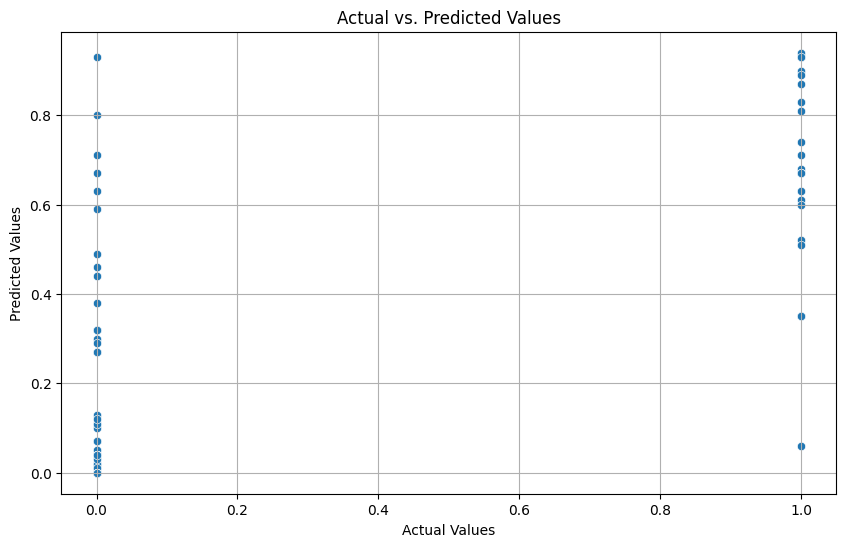

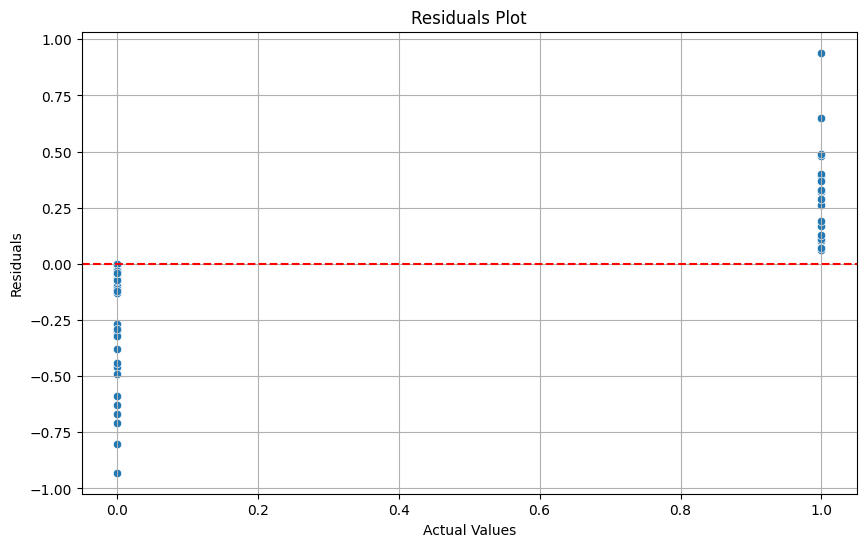

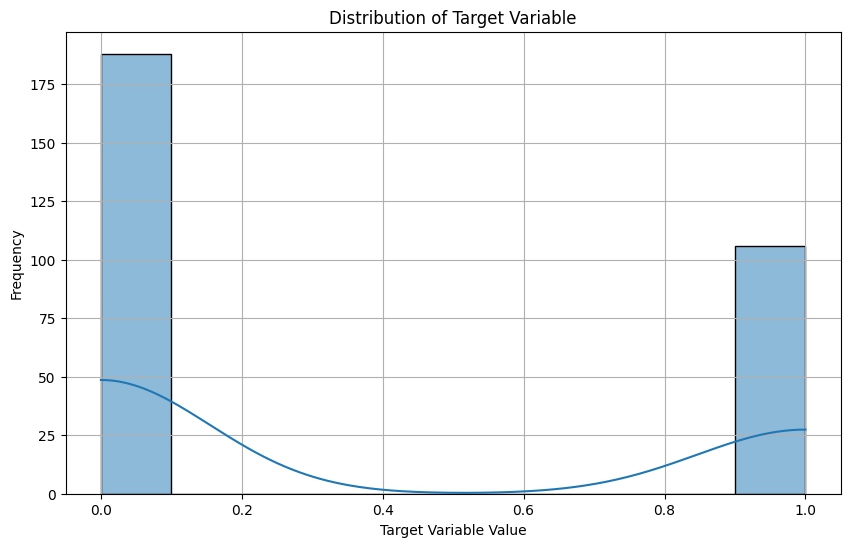

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Create a scatter plot for Actual vs. Predicted Values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)

# 3. Save the actual vs. predicted plot
plt.savefig('actual_vs_predicted.png')
plt.show()

# 4. Calculate the residuals
residuals = y_test - y_pred

# 5. Create a scatter plot for Residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.grid(True)

# 6. Save the residuals plot
plt.savefig('residuals_plot.png')
plt.show()

# 7. Create a distribution plot for the target variable y
plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True)
plt.xlabel('Target Variable Value')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable')
plt.grid(True)

# 8. Save the target variable distribution plot
plt.savefig('target_distribution.png')
plt.show()